In [1]:
import numpy as np
from keras.models import load_model
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.layers import Average, Input
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#function to get predictions from a model
def get_model_predictions(model, X):
    return model.predict(X)

In [3]:
# Load models
model1 = load_model('MODElS/CNN_LTSM10.h5')
model2 = load_model('MODElS/CNN10.h5')
model3 = load_model('MODElS/CNNbi10.h5')
model_vgg16 = load_model('MODElS/PHYSIOvgg.h5')
model_inception = load_model('MODElS/PHYSIOinception.h5')
model_resnet = load_model('MODElS/PHYSIOresnet.h5')

In [4]:
# Load test datasets
X_test = np.load('TEST1/X_test.npy')
y_test = np.load('TEST1/y_test.npy')
X_test_resized = np.load('TEST2/X_test_resized.npy')
y_test_resized = np.load('TEST2/y_test_resized.npy')

In [7]:
from tensorflow.keras.applications.vgg16 import preprocess_input as preprocess_input_vgg
from tensorflow.keras.applications.inception_v3 import preprocess_input as preprocess_input_inception
from tensorflow.keras.applications.resnet50 import preprocess_input as preprocess_input_resnet
# Preprocess the data for each model
X_test_resized_vgg = preprocess_input_vgg(np.repeat(X_test_resized, 3, axis=-1))
X_test_resized_inception = preprocess_input_inception(np.repeat(X_test_resized, 3, axis=-1))
X_test_resized_resnet = preprocess_input_resnet(np.repeat(X_test_resized, 3, axis=-1))

In [8]:
# Prepare the data for stacking by concatenating the predictions
X_test_meta = np.concatenate([
    get_model_predictions(model1, X_test),
    get_model_predictions(model2, X_test),
    get_model_predictions(model3, X_test),
    get_model_predictions(model_vgg16, X_test_resized_vgg),
    get_model_predictions(model_inception, X_test_resized_inception),
    get_model_predictions(model_resnet, X_test_resized_resnet)
], axis=1)

# Create the base estimators
estimators = [
    ('model1', make_pipeline(StandardScaler(), LogisticRegression())),
    ('model2', make_pipeline(StandardScaler(), LogisticRegression())),
    ('model3', make_pipeline(StandardScaler(), LogisticRegression())),
    ('model_vgg16', make_pipeline(StandardScaler(), LogisticRegression())),
    ('model_inception', make_pipeline(StandardScaler(), LogisticRegression())),
    ('model_resnet', make_pipeline(StandardScaler(), LogisticRegression()))
]

# Create the stacking classifier
stacking_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression()
)

# Train the stacking classifier
stacking_clf.fit(X_test_meta, y_test)

62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step
62/62 ━━━━━━━━━━━━━━━━━━━━ 56s 899ms/step
62/62 ━━━━━━━━━━━━━━━━━━━━ 14s 202ms/step
62/62 ━━━━━━━━━━━━━━━━━━━━ 26s 402ms/step


StackingClassifier(estimators=[('model1',
                                Pipeline(steps=[('standardscaler',
                                                 StandardScaler()),
                                                ('logisticregression',
                                                 LogisticRegression())])),
                               ('model2',
                                Pipeline(steps=[('standardscaler',
                                                 StandardScaler()),
                                                ('logisticregression',
                                                 LogisticRegression())])),
                               ('model3',
                                Pipeline(steps=[('standardscaler',
                                                 StandardScaler()),
                                                ('logisticregression',
                                                 LogisticRegressio...
                                Pipeline(steps=[('standardscaler',
                                                 StandardScaler()),
                                                ('logisticregression',
                                                 LogisticRegression())])),
                               ('model_inception',
                                Pipeline(steps=[('standardscaler',
                                                 StandardScaler()),
                                                ('logisticregression',
                                                 LogisticRegression())])),
                               ('model_resnet',
                                Pipeline(steps=[('standardscaler',
                                                 StandardScaler()),
                                                ('logisticregression',
                                                 LogisticRegression())]))],
                   final_estimator=LogisticRegression())

In [9]:
# Make predictions with the stacking classifier
y_pred_stacking = stacking_clf.predict(X_test_meta)

# Evaluate the ensemble model
accuracy_stacking = accuracy_score(y_test, y_pred_stacking)
conf_matrix_stacking = confusion_matrix(y_test, y_pred_stacking)
class_report_stacking = classification_report(y_test, y_pred_stacking)
roc_auc_stacking = roc_auc_score(y_test, stacking_clf.predict_proba(X_test_meta), multi_class='ovr')

print(f"Stacking Ensemble Accuracy: {accuracy_stacking}")
print("Stacking Ensemble Classification Report:")
print(class_report_stacking)
print(f"Stacking Ensemble ROC AUC Score: {roc_auc_stacking}")

Stacking Ensemble Accuracy: 0.9888832743810005
Stacking Ensemble Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       185
           1       0.99      0.99      0.99      1137
           2       0.99      0.98      0.98       627
           3       1.00      0.93      0.97        30

    accuracy                           0.99      1979
   macro avg       0.99      0.97      0.98      1979
weighted avg       0.99      0.99      0.99      1979

Stacking Ensemble ROC AUC Score: 0.9954458332671134


In [10]:
# Calculate the true and false predictions
true_correct_stacking = np.sum(y_test == y_pred_stacking)
false_predictions_stacking = np.sum(y_test != y_pred_stacking)

print(f"Stacking Ensemble True Correct Predictions: {true_correct_stacking}")
print(f"Stacking Ensemble False Predictions: {false_predictions_stacking}")

Stacking Ensemble True Correct Predictions: 1957
Stacking Ensemble False Predictions: 22


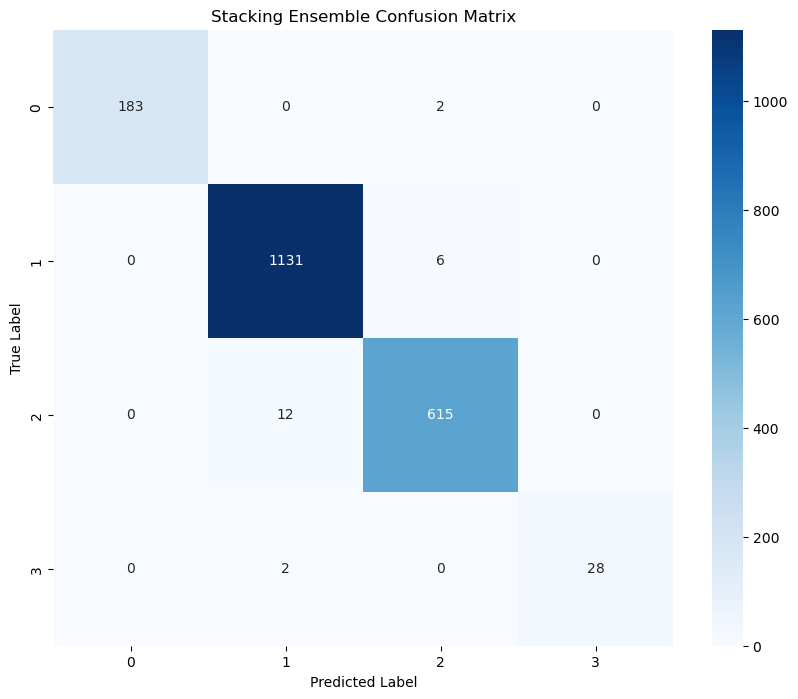

In [11]:
# Plot confusion matrix for stacking ensemble
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_stacking, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Stacking Ensemble Confusion Matrix')
plt.show()

In [13]:
import joblib
# Save the stacking classifier
joblib.dump(stacking_clf, 'MODELS/ALLPHYSIO_stacking_clf.pkl')

# Save the test set for the ensemble model
np.save('TEST1/X_test_meta_all.npy', X_test_meta)

In [14]:
# Load the stacking classifiers and their test meta-data
stacking_clf1 = joblib.load('MODElS/stacking_ensemble_model.pkl')
X_test_meta1 = np.load('TEST1/X_test_meta_.npy')

In [15]:
stacking_clf2 = joblib.load('MODELS/PHYSIO_stacking_clf.pkl')
X_test_meta2 = np.load('TEST2/X_test_meta_PHYSIO.npy')

C:\Users\user\anaconda3\Lib\site-packages\sklearn\base.py:347: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.2.2 when using version 1.3.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\user\anaconda3\Lib\site-packages\sklearn\base.py:347: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.2.2 when using version 1.3.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\user\anaconda3\Lib\site-packages\sklearn\base.py:347: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.2.2 when using version 1.3.0. This might lead to breaking code

In [16]:
# Calculate accuracy for each model
accuracy_model1 = accuracy_score(y_test, np.argmax(get_model_predictions(model1, X_test), axis=1))
accuracy_model2 = accuracy_score(y_test, np.argmax(get_model_predictions(model2, X_test), axis=1))
accuracy_model3 = accuracy_score(y_test, np.argmax(get_model_predictions(model3, X_test), axis=1))
accuracy_model_vgg16 = accuracy_score(y_test_resized, np.argmax(get_model_predictions(model_vgg16, X_test_resized_vgg), axis=1))
accuracy_model_inception = accuracy_score(y_test_resized, np.argmax(get_model_predictions(model_inception, X_test_resized_inception), axis=1))
accuracy_model_resnet = accuracy_score(y_test_resized, np.argmax(get_model_predictions(model_resnet, X_test_resized_resnet), axis=1))
accuracy_stacking1 = accuracy_score(y_test, stacking_clf1.predict(X_test_meta1))
accuracy_stacking2 = accuracy_score(y_test, stacking_clf2.predict(X_test_meta2))
accuracy_stacking = accuracy_score(y_test, stacking_clf.predict(X_test_meta))

62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
62/62 ━━━━━━━━━━━━━━━━━━━━ 35s 563ms/step
62/62 ━━━━━━━━━━━━━━━━━━━━ 8s 126ms/step
62/62 ━━━━━━━━━━━━━━━━━━━━ 18s 291ms/step


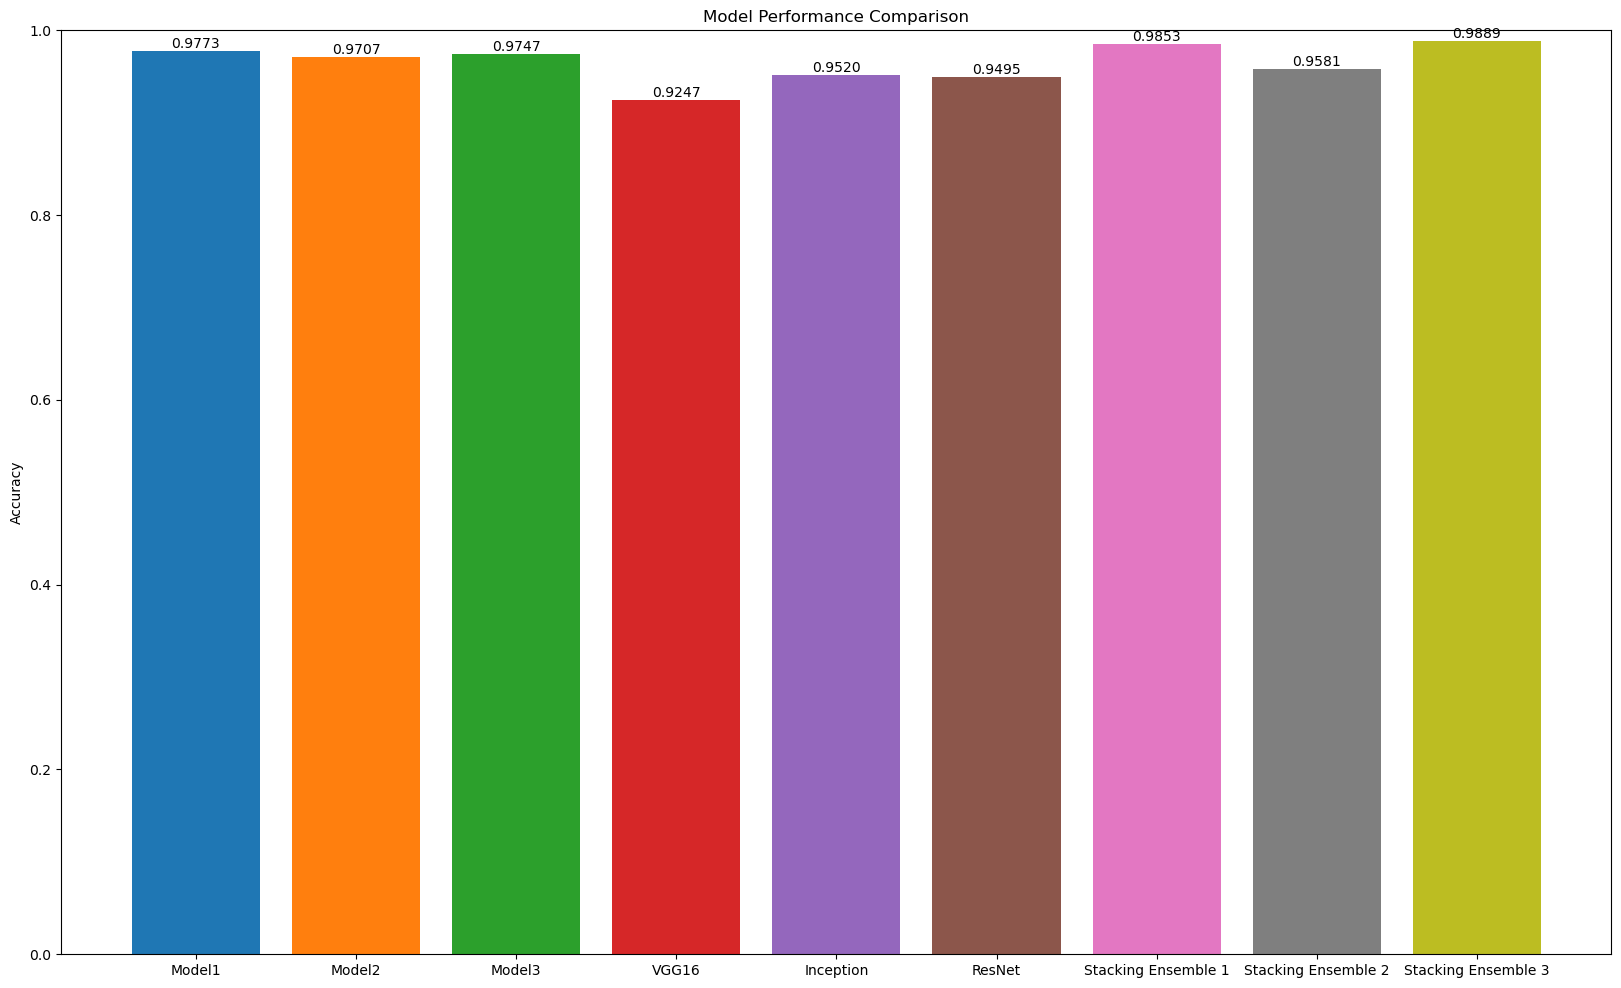

In [24]:
# Compare all models' performance 
model_names = ["Model1", "Model2", "Model3", "VGG16", "Inception", "ResNet", "Stacking Ensemble 1", "Stacking Ensemble 2", "Stacking Ensemble 3"]
accuracies = [accuracy_model1, accuracy_model2, accuracy_model3, accuracy_model_vgg16, accuracy_model_inception, accuracy_model_resnet, accuracy_stacking1, accuracy_stacking2, accuracy_stacking]

# Define colors for each model
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22']

plt.figure(figsize=(20, 12))
plt.bar(model_names, accuracies, color=colors)
plt.ylabel('Accuracy')
plt.title('Model Performance Comparison')
plt.ylim(0, 1)
for index, value in enumerate(accuracies):
    plt.text(index, value, f'{value:.4f}', ha='center', va='bottom')
plt.show()